The goal of the competition is to predict whether or not some users (whose user ids are in the test file) will churn in the window of 10 days that follows the given observations (ie \** after "2018-11-20" *\* ). We consider that a user churns when they visit the page 'Cancellation Confirmation'

In [ ]:
import pandas as pd
import sys
import os
BASE_PATH = os.getcwd()
sys.path.append(BASE_PATH)

train_path = f"{BASE_PATH}/churn-prediction-25-26/train.parquet"
test_path  = f"{BASE_PATH}/churn-prediction-25-26/test.parquet"


In [ ]:

train = pd.read_parquet(train_path)
test  = pd.read_parquet(test_path)

In [ ]:
train.time.max(), train.time.min()

(Timestamp('2018-11-20 00:00:00'), Timestamp('2018-10-01 00:00:01'))

In [ ]:
train = train.sort_values(by = ['userId', 'time'])

In [ ]:
train.head()

,status,gender,firstName,level,lastName,userId,ts,auth,page,sessionId,location,itemInSession,userAgent,method,length,song,artist,time,registration
403570,200,M,Camren,free,Walker,1000025,1538470769000,Logged In,Home,23706,"New Haven-Milford, CT",0,"""Mozilla/5.0 (Windows NT 6.1; WOW64) AppleWebK...",GET,NaN,None,None,2018-10-02 08:59:29,2018-07-10 09:30:08
404235,200,M,Camren,free,Walker,1000025,1538470964000,Logged In,NextSong,23706,"New Haven-Milford, CT",1,"""Mozilla/5.0 (Windows NT 6.1; WOW64) AppleWebK...",PUT,251.97669,Underground,1001,2018-10-02 09:02:44,2018-07-10 09:30:08
405134,200,M,Camren,free,Walker,1000025,1538471215000,Logged In,NextSong,23706,"New Haven-Milford, CT",2,"""Mozilla/5.0 (Windows NT 6.1; WOW64) AppleWebK...",PUT,223.05914,AsesÃÂ­name,Charly GarcÃÂ­a,2018-10-02 09:06:55,2018-07-10 09:30:08
405929,200,M,Camren,free,Walker,1000025,1538471438000,Logged In,NextSong,23706,"New Haven-Milford, CT",3,"""Mozilla/5.0 (Windows NT 6.1; WOW64) AppleWebK...",PUT,193.38404,Last Nite,The Strokes,2018-10-02 09:10:38,2018-07-10 09:30:08
406597,200,M,Camren,free,Walker,1000025,1538471631000,Logged In,NextSong,23706,"New Haven-Milford, CT",4,"""Mozilla/5.0 (Windows NT 6.1; WOW64) AppleWebK...",PUT,177.37098,The End,Pearl Jam,2018-10-02 09:13:51,2018-07-10 09:30:08


In [ ]:
train.loc[train['page'] == 'Cancellation Confirmation']


,status,gender,firstName,level,lastName,userId,ts,auth,page,sessionId,location,itemInSession,userAgent,method,length,song,artist,time,registration
5929703,200,M,Camren,paid,Walker,1000025,1539894785000,Cancelled,Cancellation Confirmation,95858,"New Haven-Milford, CT",120,"""Mozilla/5.0 (Windows NT 6.1; WOW64) AppleWebK...",GET,NaN,None,None,2018-10-18 20:33:05,2018-07-10 09:30:08
3771849,200,M,Grady,paid,Jensen,1000083,1539338698000,Cancelled,Cancellation Confirmation,72494,"Cincinnati, OH-KY-IN",148,"""Mozilla/5.0 (Windows NT 6.3; WOW64) AppleWebK...",GET,NaN,None,None,2018-10-12 10:04:58,2018-09-07 18:01:49
22478579,200,M,Frank,free,Warren,1000280,1542149985000,Cancelled,Cancellation Confirmation,25840,"Findlay, OH",138,Mozilla/5.0 (Windows NT 5.1; rv:31.0) Gecko/20...,GET,NaN,None,None,2018-11-13 22:59:45,2018-08-28 15:42:19
7191245,200,F,Phoebe,paid,Frederick,1000353,1540247149000,Cancelled,Cancellation Confirmation,35478,"Wichita Falls, TX",111,"""Mozilla/5.0 (Windows NT 6.1; WOW64) AppleWebK...",GET,NaN,None,None,2018-10-22 22:25:49,2018-05-02 11:37:39
21576634,200,F,Saraya,paid,Anderson,1000503,1539396428000,Cancelled,Cancellation Confirmation,7092,"Boston-Cambridge-Newton, MA-NH",140,Mozilla/5.0 (Windows NT 6.1; WOW64; rv:31.0) G...,GET,NaN,None,None,2018-10-13 02:07:08,2018-06-30 11:05:49
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20793185,200,M,Nicholas,paid,Gordon,1999022,1541304586000,Cancelled,Cancellation Confirmation,16078,"New York-Newark-Jersey City, NY-NJ-PA",138,"""Mozilla/5.0 (Macintosh; Intel Mac OS X 10_9_4...",GET,NaN,None,None,2018-11-04 04:09:46,2018-09-22 21:31:14
19896794,200,M,Jax,free,Evans,1999035,1538398263000,Cancelled,Cancellation Confirmation,3257,"Stephenville, TX",10,Mozilla/5.0 (Windows NT 6.0; rv:31.0) Gecko/20...,GET,NaN,None,None,2018-10-01 12:51:03,2018-04-29 14:07:05
19931917,200,F,Tessa,free,Powell,1999668,1538450578000,Cancelled,Cancellation Confirmation,2279,"Beaumont-Port Arthur, TX",51,"""Mozilla/5.0 (Windows NT 6.1; WOW64) AppleWebK...",GET,NaN,None,None,2018-10-02 03:22:58,2018-09-03 11:44:46
20458613,200,F,Khloe,paid,Kelley,1999847,1539828646000,Cancelled,Cancellation Confirmation,11005,"Columbus, OH",266,"""Mozilla/5.0 (Windows NT 6.3; WOW64) AppleWebK...",GET,NaN,None,None,2018-10-18 02:10:46,2018-09-26 04:22:19


In [ ]:
train.loc[train['userId'] == '1222580']

,status,gender,firstName,level,lastName,userId,ts,auth,page,sessionId,location,itemInSession,userAgent,method,length,song,artist,time,registration
3,200,M,Andres,paid,Foley,1222580,1538352003000,Logged In,NextSong,6370,"Watertown, SD",71,"""Mozilla/5.0 (Macintosh; Intel Mac OS X 10_9_4...",PUT,277.15873,Horn Concerto No. 4 in E flat K495: II. Romanc...,Barry Tuckwell/Academy of St Martin-in-the-Fie...,2018-10-01 00:00:03,2018-08-16 02:31:00
517,200,M,Andres,paid,Foley,1222580,1538352280000,Logged In,NextSong,6370,"Watertown, SD",72,"""Mozilla/5.0 (Macintosh; Intel Mac OS X 10_9_4...",PUT,271.01995,Violins,Joey Cape,2018-10-01 00:04:40,2018-08-16 02:31:00
1044,200,M,Andres,paid,Foley,1222580,1538352551000,Logged In,NextSong,6370,"Watertown, SD",73,"""Mozilla/5.0 (Macintosh; Intel Mac OS X 10_9_4...",PUT,208.69179,She Said,Plan B,2018-10-01 00:09:11,2018-08-16 02:31:00
1473,200,M,Andres,paid,Foley,1222580,1538352759000,Logged In,NextSong,6370,"Watertown, SD",74,"""Mozilla/5.0 (Macintosh; Intel Mac OS X 10_9_4...",PUT,344.00608,Communication,Black Eyed Peas,2018-10-01 00:12:39,2018-08-16 02:31:00
2176,200,M,Andres,paid,Foley,1222580,1538353103000,Logged In,NextSong,6370,"Watertown, SD",75,"""Mozilla/5.0 (Macintosh; Intel Mac OS X 10_9_4...",PUT,157.09995,The Rocky Road to Dublin (Album Version),Dropkick Murphys,2018-10-01 00:18:23,2018-08-16 02:31:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9994610,200,M,Andres,paid,Foley,1222580,1540941234000,Logged In,NextSong,132552,"Watertown, SD",176,"""Mozilla/5.0 (Macintosh; Intel Mac OS X 10_9_4...",PUT,202.37016,Cross The Tracks (We Better Go Back),Maceo And The Macks,2018-10-30 23:13:54,2018-08-16 02:31:00
9995549,200,M,Andres,paid,Foley,1222580,1540941436000,Logged In,NextSong,132552,"Watertown, SD",177,"""Mozilla/5.0 (Macintosh; Intel Mac OS X 10_9_4...",PUT,217.88689,Big Legs,Steve Johnson,2018-10-30 23:17:16,2018-08-16 02:31:00
9995581,200,M,Andres,paid,Foley,1222580,1540941445000,Logged In,Roll Advert,132552,"Watertown, SD",178,"""Mozilla/5.0 (Macintosh; Intel Mac OS X 10_9_4...",GET,NaN,None,None,2018-10-30 23:17:25,2018-08-16 02:31:00
9995587,307,M,Andres,paid,Foley,1222580,1540941446000,Logged In,Cancel,132552,"Watertown, SD",179,"""Mozilla/5.0 (Macintosh; Intel Mac OS X 10_9_4...",PUT,NaN,None,None,2018-10-30 23:17:26,2018-08-16 02:31:00


In [ ]:
cancel_df = train[train['userId'].isin(cancel_users)]

last_rows = cancel_df.groupby('userId').tail(1)

all_last_fast = (last_rows['page'] == 'Cancellation Confirmation').all()

if all_last_fast:
    print("all that userId have 'Cancellation Confirmation' This is the last message")
else:   
    invalid_users = last_rows.loc[last_rows['page'] != 'Cancellation Confirmation', 'userId'].tolist()
    print(f"exist userId that the last message is not 'Cancellation Confirmation': {invalid_users}")


NameError: name 'cancel_users' is not defined

KeyboardInterrupt: 

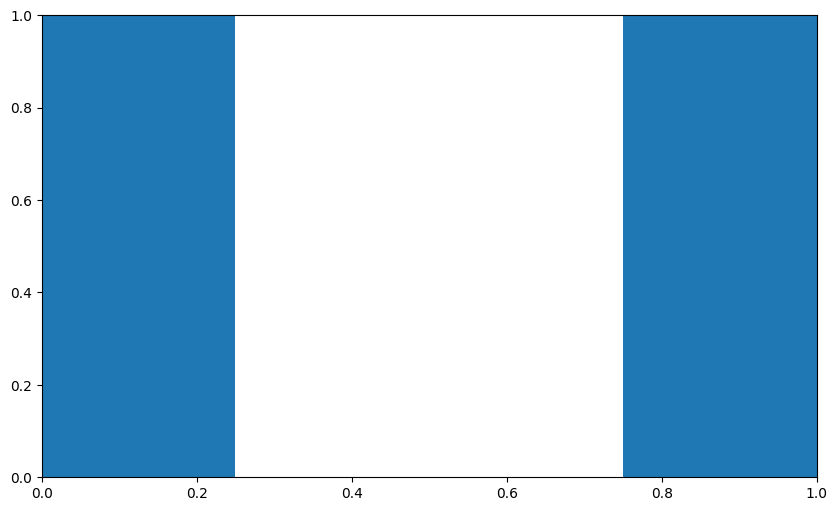

In [ ]:
user_counts = train.groupby('userId').size()

user_counts

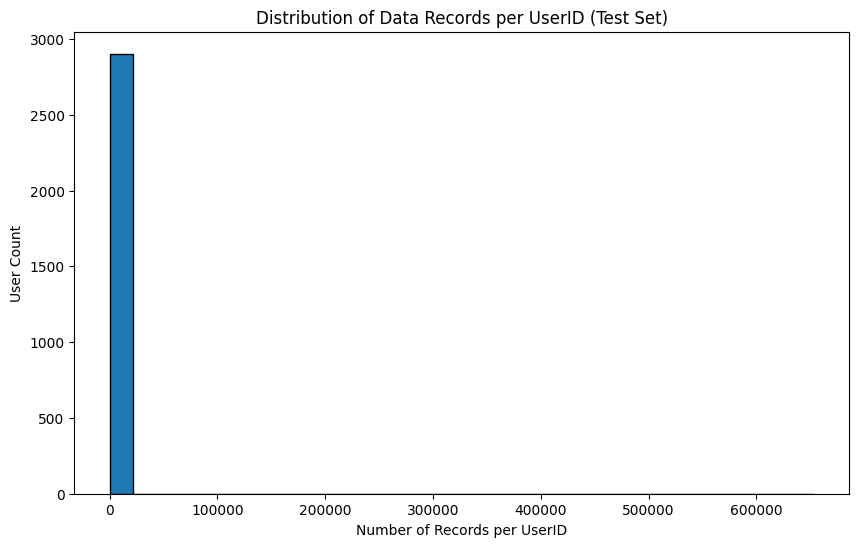

In [ ]:
user_counts_test = test.groupby('userId').size()

user_counts_test



In [ ]:
test.time.max(), test.time.min()

(Timestamp('2018-11-20 00:00:00'), Timestamp('2018-10-01 00:00:06'))

In [ ]:
train.time.max(), train.time.min()

(Timestamp('2018-11-20 00:00:00'), Timestamp('2018-10-01 00:00:01'))

In [ ]:
test.loc[test['page'] == 'Cancellation Confirmation']

,status,gender,firstName,level,lastName,userId,ts,auth,page,sessionId,location,itemInSession,userAgent,method,length,song,artist,time,registration


In [ ]:
test

,status,gender,firstName,level,lastName,userId,ts,auth,page,sessionId,location,itemInSession,userAgent,method,length,song,artist,time,registration
7,200,M,Jonathan,free,Martin,1465194,1538352006000,Logged In,NextSong,22483,"New York-Newark-Jersey City, NY-NJ-PA",29,"""Mozilla/5.0 (Windows NT 6.1; WOW64) AppleWebK...",PUT,250.82730,Mockingbird,Eminem,2018-10-01 00:00:06,2018-09-27 17:29:36
54,200,M,Jonathan,free,Martin,1465194,1538352028000,Logged In,Roll Advert,22483,"New York-Newark-Jersey City, NY-NJ-PA",30,"""Mozilla/5.0 (Windows NT 6.1; WOW64) AppleWebK...",GET,NaN,None,None,2018-10-01 00:00:28,2018-09-27 17:29:36
477,200,M,Jonathan,free,Martin,1465194,1538352256000,Logged In,NextSong,22483,"New York-Newark-Jersey City, NY-NJ-PA",31,"""Mozilla/5.0 (Windows NT 6.1; WOW64) AppleWebK...",PUT,355.78730,Thank You (Precious Memories Album Version),Ray Boltz,2018-10-01 00:04:16,2018-09-27 17:29:36
1170,200,M,Jonathan,free,Martin,1465194,1538352611000,Logged In,NextSong,22483,"New York-Newark-Jersey City, NY-NJ-PA",32,"""Mozilla/5.0 (Windows NT 6.1; WOW64) AppleWebK...",PUT,191.68608,Mathletics,Foals,2018-10-01 00:10:11,2018-09-27 17:29:36
1552,200,M,Jonathan,free,Martin,1465194,1538352802000,Logged In,NextSong,22483,"New York-Newark-Jersey City, NY-NJ-PA",33,"""Mozilla/5.0 (Windows NT 6.1; WOW64) AppleWebK...",PUT,275.25179,Proceed,The Roots,2018-10-01 00:13:22,2018-09-27 17:29:36
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25660576,200,F,Lariyah,free,Lamb,1394356,1542670678000,Logged In,NextSong,2540,"Medford, OR",122,"""Mozilla/5.0 (Windows NT 6.3; WOW64) AppleWebK...",PUT,312.63302,One Headlight,The Wallflowers,2018-11-19 23:37:58,2018-11-19 16:36:59
25660839,200,F,Lariyah,free,Lamb,1394356,1542670990000,Logged In,NextSong,2540,"Medford, OR",123,"""Mozilla/5.0 (Windows NT 6.3; WOW64) AppleWebK...",PUT,222.30159,First Dance,Justin Bieber / Usher,2018-11-19 23:43:10,2018-11-19 16:36:59
25661027,200,F,Lariyah,free,Lamb,1394356,1542671212000,Logged In,NextSong,2540,"Medford, OR",124,"""Mozilla/5.0 (Windows NT 6.3; WOW64) AppleWebK...",PUT,447.42485,One,Metallica,2018-11-19 23:46:52,2018-11-19 16:36:59
25661312,200,F,Lariyah,free,Lamb,1394356,1542671574000,Logged In,Upgrade,2540,"Medford, OR",125,"""Mozilla/5.0 (Windows NT 6.3; WOW64) AppleWebK...",GET,NaN,None,None,2018-11-19 23:52:54,2018-11-19 16:36:59
